<a href="https://colab.research.google.com/github/bburugap/ores5160-2026/blob/main/week07/week07_assignment_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Here is the data for this esercise:**
Download the following file and upload it using the code block above. Then rename the long file name to airquality.csv.

https://drive.google.com/file/d/1SBD8R6jl5_ycl3X7hulrlHpqR-w3i__a/view?usp=drive_link

The information below is for licensing compliance purposes per dataset owner instructions.

License: https://creativecommons.org/licenses/by-sa/4.0/.
Data Source: https://openaq.org/#/about.
Changes: Subset by country US and limited to the most recent week of data in the dataset
The interactive tables feature only supports 20,000 rows, and this file has a lot more than that, so we are going to read it in and tell Pandas to only look at the first 10,000 rows. When we are just getting a sense for the type of data in the file, this is fine. Later if we need to read all of the data, we can simply remove the nrows= flag from the code.

Instructions


*   Use Google Colab or your preferred Python environment.
*   Upload the dataset(s) as instructed in each question.




Q1. Upload and Preview Data

	1.	Upload the file airquality.csv to your Colab environment.\\
       
	2.	Load the first 10,000 rows into a Pandas dataframe called airquality.\\

	3.	Display the first 5 rows of the dataframe.\\

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving edited_us_air_quality_one_week_2022_06_23.csv to edited_us_air_quality_one_week_2022_06_23.csv
User uploaded file "edited_us_air_quality_one_week_2022_06_23.csv" with length 19367489 bytes


In [ ]:
import pandas as pd

In [ ]:
airquality = pd.read_csv("airquality.csv", nrows=10000)

In [ ]:
airquality.head(5)

,location,city,country,pollutant,value,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom,date,time
0,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,0.33,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-26,05:00:00
1,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,1.68,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-19,07:00:00
2,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,0.63,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-25,20:00:00
3,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,1.86,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-20,04:00:00
4,MILWAUKEE COLLEGE AV,Milwaukee-Waukesha-West Allis,US,bc,0.33,µg/m³,AirNow,1,42.93257,-87.93434,POINT(42.93257 1),2022-05-25,10:00:00


Q2. Data Summary and Cleaning

	1.	Use .info() and .describe(include="all") to explore the dataset.\\

	2.	Identify any columns that have missing (NaN) values.\\

	3.	Drop all rows that contain missing values.\\

In [ ]:
airquality_all = pd.read_csv("airquality.csv")

In [ ]:
airquality_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170579 entries, 0 to 170578
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   location                170524 non-null  object 
 1   city                    170251 non-null  object 
 2   country                 170579 non-null  object 
 3   pollutant               170579 non-null  object 
 4   value                   170579 non-null  float64
 5   unit                    170579 non-null  object 
 6   source_name             170579 non-null  object 
 7   latitude                170579 non-null  int64  
 8   longitude               170579 non-null  float64
 9   averaged_over_in_hours  170579 non-null  float64
 10  location_geom           170579 non-null  object 
 11  date                    170579 non-null  object 
 12  time                    170579 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 16.9+ MB


In [ ]:
airquality_all.describe(include="all")

,location,city,country,pollutant,value,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom,date,time
count,170524,170251,170579,170579,170579.000000,170579,170579,170579.0,170579.000000,170579.000000,170579,170579,170579
unique,1700,707,1,7,NaN,2,1,NaN,NaN,NaN,1726,8,24
top,NCORE,Phoenix-Mesa-Scottsdale,US,o3,NaN,ppm,AirNow,NaN,NaN,NaN,POINT(33.999449 1),2022-05-25,22:00:00
freq,713,4578,170579,61443,NaN,97827,170579,NaN,NaN,NaN,605,24042,17124
mean,NaN,NaN,NaN,NaN,5.438086,NaN,NaN,1.0,38.522299,-98.090892,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,17.721798,NaN,NaN,0.0,5.374290,18.804357,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-9.700000,NaN,NaN,1.0,0.410931,-158.088593,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.023000,NaN,NaN,1.0,35.050800,-116.031970,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,0.050000,NaN,NaN,1.0,38.876300,-94.167436,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,1.0,41.783083,-82.264944,NaN,NaN,NaN


In [ ]:
has_any_nulls_df = airquality_all.isnull().values.any()
print (has_any_nulls_df)

True


In [ ]:
import numpy as np

In [ ]:
# Replace infinite updated data with nan using NumPy
airquality_all.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN
airquality_all.dropna(inplace=True)

# Look at the results
airquality_all.describe(include='all')

,location,city,country,pollutant,value,unit,source_name,latitude,longitude,averaged_over_in_hours,location_geom,date,time
count,170196,170196,170196,170196,170196.000000,170196,170196,170196.0,170196.000000,170196.000000,170196,170196,170196
unique,1697,706,1,7,NaN,2,1,NaN,NaN,NaN,1722,8,24
top,NCORE,Phoenix-Mesa-Scottsdale,US,o3,NaN,ppm,AirNow,NaN,NaN,NaN,POINT(33.999449 1),2022-05-25,22:00:00
freq,713,4578,170196,61279,NaN,97663,170196,NaN,NaN,NaN,605,23986,17086
mean,NaN,NaN,NaN,NaN,5.418950,NaN,NaN,1.0,38.520702,-98.075094,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,17.664508,NaN,NaN,0.0,5.374297,18.802811,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-9.700000,NaN,NaN,1.0,0.410931,-158.088593,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,0.023000,NaN,NaN,1.0,35.054400,-115.996263,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,0.050000,NaN,NaN,1.0,38.876300,-94.143300,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,1.0,41.783083,-82.264944,NaN,NaN,NaN


Q3. Data Visualization

	1.	Create a histogram of the pm25 values.\\

	2.	Create a boxplot for the pm25 column.\\


<Axes: >

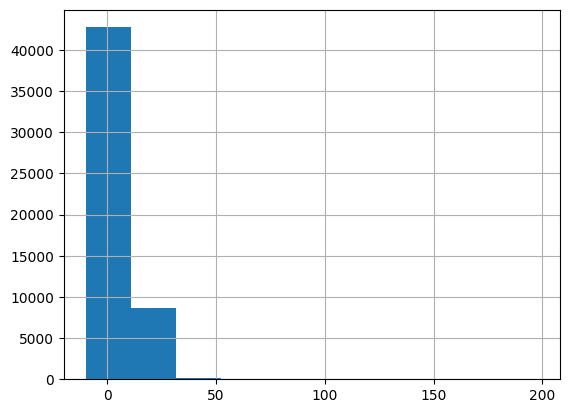

In [ ]:


airquality_all[airquality_all['pollutant'] == 'pm25']['value'].hist()

<Axes: >

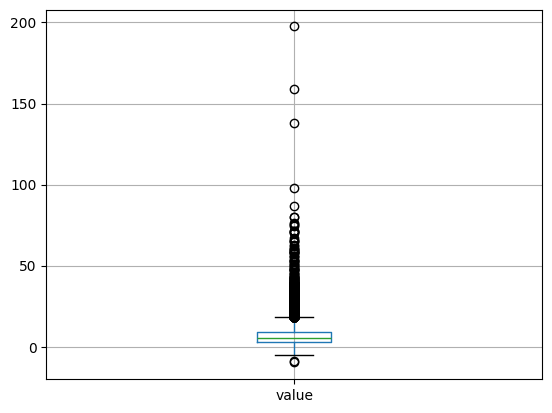

In [ ]:
airquality_all[airquality_all['pollutant'] == 'pm25'].boxplot(column='value')


## Submitting Your Work

Save you work to the path week07/week07_assignment_pandas.ipynb